# Graficas del metodo de Sturm (Litio)

Este notebook grafica y compara resultados de Sturm contra DF (Leonardo).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
cwd = Path('.').resolve()

# Detecta automaticamente desde donde se esta ejecutando el notebook
sturm_candidates = [
    cwd,
    cwd / 'sturmSequence',
    cwd / 'PARCIAL' / 'sturmSequence',
]

sturm_dir = None
for cand in sturm_candidates:
    if (cand / 'LITIO_STURM0.DAT').exists() and (cand / 'LITIO_STURM1.DAT').exists():
        sturm_dir = cand
        break

if sturm_dir is None:
    sturm_dir = cwd

parcial_dir = sturm_dir.parent if sturm_dir.name == 'sturmSequence' else sturm_dir
df_dir = parcial_dir / 'finite-diferences'

f_sturm_s = sturm_dir / 'LITIO_STURM0.DAT'
f_sturm_p = sturm_dir / 'LITIO_STURM1.DAT'
f_energy_df = df_dir / 'energias_litio_leonardo.dat'
f_wave_df = df_dir / 'funciones_radiales_litio_fortran_leonardo.DAT'

required = [f_sturm_s, f_sturm_p, f_energy_df, f_wave_df]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Faltan archivos:\n' + '\n'.join(missing))

print('Leyendo Sturm s:', f_sturm_s)
print('Leyendo Sturm p:', f_sturm_p)
print('Leyendo DF energia:', f_energy_df)
print('Leyendo DF funciones:', f_wave_df)

Leyendo Sturm s: /home/isabel/MFC/PARCIAL/sturmSequence/LITIO_STURM0.DAT
Leyendo Sturm p: /home/isabel/MFC/PARCIAL/sturmSequence/LITIO_STURM1.DAT
Leyendo DF energia: /home/isabel/MFC/PARCIAL/finite-diferences/energias_litio_leonardo.dat
Leyendo DF funciones: /home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT


In [3]:
def load_energy_table(path):
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = parts[0]
            try:
                out[label] = float(parts[-1])
            except ValueError:
                continue
    return out

def load_sturm_blocks(path):
    arr = np.loadtxt(path)
    r = arr[:, 0]
    u = arr[:, 1]
    cuts = np.where(np.diff(r) < 0.0)[0]
    starts = [0] + (cuts + 1).tolist()
    ends = cuts.tolist() + [len(r)]
    blocks = []
    for i0, i1 in zip(starts, ends):
        blocks.append((r[i0:i1], u[i0:i1]))
    return blocks

states = ['2s', '3s', '4s', '2p', '3p', '3d']
df_e = load_energy_table(f_energy_df)

# Energias Sturm (eV) obtenidas al ejecutar sturm_litio.f90 por canal l=0,1,2
sturm_e = {
    '2s': -4.843899925619266,
    '3s': -1.8892850761704838,
    '4s': -0.7494196762770297,
    '2p': -3.4320668372815932,
    '3p': -1.5056226314273760,
    '3d': -1.5054203872518701,
}

comp = pd.DataFrame({
    'estado': states,
    'E_eV_df': [df_e[s] for s in states],
    'E_eV_sturm': [sturm_e[s] for s in states],
})
comp['Delta_eV_sturm_minus_df'] = comp['E_eV_sturm'] - comp['E_eV_df']

wave_df = np.loadtxt(f_wave_df, skiprows=1)
r_df = wave_df[:, 0]
R_df = {
    '2s': wave_df[:, 2],
    '3s': wave_df[:, 3],
    '4s': wave_df[:, 4],
    '2p': wave_df[:, 5],
    '3p': wave_df[:, 6],
    '3d': wave_df[:, 7],
}

blocks_s = load_sturm_blocks(f_sturm_s)
blocks_p = load_sturm_blocks(f_sturm_p)
if len(blocks_s) < 4:
    raise ValueError('LITIO_STURM0.DAT debe contener al menos 4 bloques (1s,2s,3s,4s).')
if len(blocks_p) < 2:
    raise ValueError('LITIO_STURM1.DAT debe contener al menos 2 bloques (2p,3p).')

R_st = {
    '2s': blocks_s[1],
    '3s': blocks_s[2],
    '4s': blocks_s[3],
    '2p': blocks_p[0],
    '3p': blocks_p[1],
}

print('Tabla de energias DF vs Sturm:')
display(comp)

Tabla de energias DF vs Sturm:


,estado,E_eV_df,E_eV_sturm,Delta_eV_sturm_minus_df
0,2s,-4.701310,-4.843900,-1.425898e-01
1,3s,-1.853494,-1.889285,-3.579107e-02
2,4s,-0.720450,-0.749420,-2.897007e-02
3,2p,-3.432066,-3.432067,-3.686219e-07
4,3p,-1.505622,-1.505623,-1.404269e-07
5,3d,-1.505420,-1.505420,5.033174e-11


## Tabla bonita: energias DF vs Sturm

$$
\Delta E = E_{\text{sturm}} - E_{\text{DF}}
$$

| Estado | $E_{\text{DF}}$ (eV) | $E_{\text{sturm}}$ (eV) | $\Delta E$ (eV) |
|---|---:|---:|---:|
| 2s | -4.701310 | -4.843900 | -0.142590 |
| 3s | -1.853494 | -1.889285 | -0.035791 |
| 4s | -0.720450 | -0.749420 | -0.028970 |
| 2p | -3.432066 | -3.432067 | -0.000000 |
| 3p | -1.505622 | -1.505623 | -0.000000 |
| 3d | -1.505420 | -1.505420 | 0.000000 |

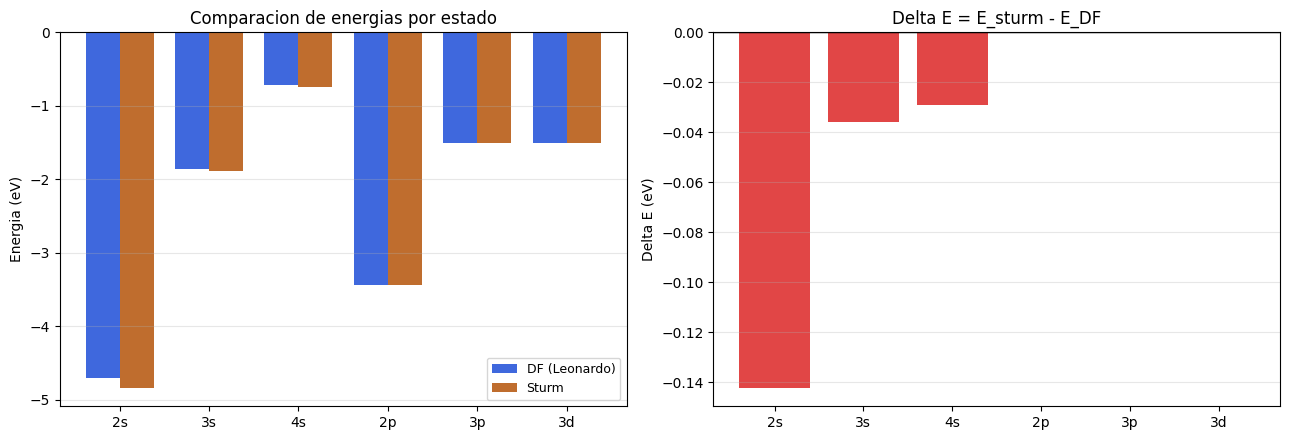

In [4]:
labels = comp['estado'].astype(str).to_list()
x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(x - w/2, comp['E_eV_df'], width=w, color='#1d4ed8', alpha=0.85, label='DF (Leonardo)')
ax[0].bar(x + w/2, comp['E_eV_sturm'], width=w, color='#b45309', alpha=0.85, label='Sturm')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_title('Comparacion de energias por estado')
ax[0].set_ylabel('Energia (eV)')
ax[0].grid(True, axis='y', alpha=0.3)
ax[0].legend(fontsize=9)

ax[1].bar(labels, comp['Delta_eV_sturm_minus_df'], color='#dc2626', alpha=0.85)
ax[1].axhline(0.0, color='black', lw=1.0)
ax[1].set_title('Delta E = E_sturm - E_DF')
ax[1].set_ylabel('Delta E (eV)')
ax[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

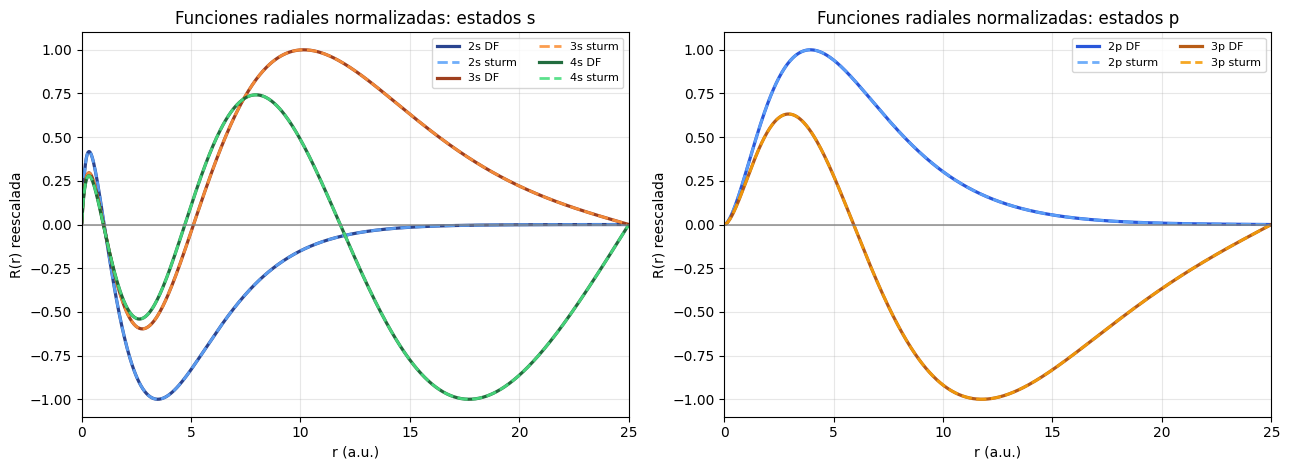

In [5]:
def normalize_in_window(r, y, rmin=0.0, rmax=25.0):
    m = (r >= rmin) & (r <= rmax)
    if not np.any(m):
        return y
    scale = np.max(np.abs(y[m]))
    if not np.isfinite(scale) or scale <= 0.0:
        return y
    return y / scale

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

# Estados s: DF oscuro y Sturm claro para apreciar superposicion
for st, col_df, col_st in [
    ('2s', '#1e3a8a', '#60a5fa'),
    ('3s', '#9a3412', '#fb923c'),
    ('4s', '#166534', '#4ade80'),
]:
    y_df = normalize_in_window(r_df, R_df[st])
    r_st, u_st = R_st[st]
    y_st = normalize_in_window(r_st, u_st)
    ax[0].plot(r_df, y_df, color=col_df, lw=2.3, alpha=0.95, label=f'{st} DF')
    ax[0].plot(r_st, y_st, color=col_st, lw=2.0, ls='--', alpha=0.9, label=f'{st} sturm')

ax[0].axhline(0.0, color='gray', lw=1.1, alpha=0.9)
ax[0].set_xlim(0.0, 25.0)
ax[0].set_ylim(-1.1, 1.1)
ax[0].set_title('Funciones radiales normalizadas: estados s')
ax[0].set_xlabel('r (a.u.)')
ax[0].set_ylabel('R(r) reescalada')
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8, ncol=2)

# Estados p (sin estados d)
for st, col_df, col_st in [
    ('2p', '#1d4ed8', '#60a5fa'),
    ('3p', '#b45309', '#f59e0b'),
]:
    y_df = normalize_in_window(r_df, R_df[st])
    r_st, u_st = R_st[st]
    y_st = normalize_in_window(r_st, u_st)
    ax[1].plot(r_df, y_df, color=col_df, lw=2.3, alpha=0.95, label=f'{st} DF')
    ax[1].plot(r_st, y_st, color=col_st, lw=2.0, ls='--', alpha=0.9, label=f'{st} sturm')

ax[1].axhline(0.0, color='gray', lw=1.1, alpha=0.9)
ax[1].set_xlim(0.0, 25.0)
ax[1].set_ylim(-1.1, 1.1)
ax[1].set_title('Funciones radiales normalizadas: estados p')
ax[1].set_xlabel('r (a.u.)')
ax[1].set_ylabel('R(r) reescalada')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()